# Tunisair Flight Delay Prediction

Predicting flight delay duration for Tunisair using pre-departure attributes (schedule, route, aircraft), following the same leakage-safe workflow as `03_eda-and-modeling.ipynb`.

## Phase 1.1: Download flight delay dataset and load into data/

Download `train.csv` and `test.csv` from the [Zindi Flight Delay Prediction Challenge](https://zindi.africa/competitions/flight-delay-prediction-challenge/data) and place them in `data/` before running this cell.

**Before this step:** We don't have any data loaded into the notebook yet — just a plan.

**What this code does:** It brings in a toolbox called `pandas` (think of it like Excel, but controlled with code) and uses it to open the two data files (`train.csv` and `test.csv`) we downloaded from Zindi. Then it shows the first 5 rows so we can see what the data actually looks like.

**What we want to get out of it:** A first real look at the raw data — the columns we have, the format they're in, and confirmation the files loaded correctly before we do anything else.

In [49]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
train.head()

,ID,DATOP,FLTID,DEPSTN,ARRSTN,STD,STA,STATUS,AC,target
0,train_id_0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12.55.00,ATA,TU 32AIMN,260.0
1,train_id_1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16.55.00,ATA,TU 31BIMO,20.0
2,train_id_2,2016-01-16,TU 0214,TUN,IST,2016-01-16 04:10:00,2016-01-16 06.45.00,ATA,TU 32AIMN,0.0
3,train_id_3,2016-01-17,TU 0480,DJE,NTE,2016-01-17 14:10:00,2016-01-17 17.00.00,ATA,TU 736IOK,0.0
4,train_id_4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15.50.00,ATA,TU 320IMU,22.0


## Phase 1.2: Add airportsdata dependency and enrich DEPSTN/ARRSTN

Join `DEPSTN`/`ARRSTN` to airport metadata via `airportsdata`.

**Before this step:** Our data only has 3-letter airport codes for where each flight departs from (`DEPSTN`) and arrives at (`ARRSTN`), like `"CMN"` or `"TUN"`. On their own, these codes don't mean anything to a model — it can't learn that `"CMN"` is in Morocco or that two airports are in different timezones just from the code itself.

**What this code does:** It uses a reference library called `airportsdata`, which is like a big lookup table of airport codes and their real-world details (country, latitude, longitude, timezone). For each airport code in our data, it looks up this information and adds it as brand new columns — `dep_country`, `dep_lat`, `dep_lon`, `dep_tz` for the departure airport, and the same with `arr_` for the arrival airport. One airport, `SXF` (Berlin-Schönefeld), isn't in that library anymore because it closed in 2020, so we added its details manually as a backup (see `ISSUES.md`).

**What we want to get out of it:** Turning meaningless 3-letter codes into useful, model-friendly information — like how far apart two airports are, or whether a flight crosses a timezone — which is more likely to help predict delays than the raw airport code alone.

In [50]:
import airportsdata

airports = airportsdata.load("IATA")

# Manual override: SXF (Berlin-Schoenefeld) was decommissioned in 2020 (merged into
# Berlin Brandenburg/BER) and is no longer in airportsdata's current tables, even
# though it's a valid code in this 2016-2018 dataset. See ISSUES.md.
AIRPORT_OVERRIDES = {
    "SXF": {"country": "DE", "lat": 52.3667, "lon": 13.5033, "tz": "Europe/Berlin"},
}


def enrich_airport_columns(df, code_col, prefix):
    def lookup(code):
        return airports.get(code) or AIRPORT_OVERRIDES.get(code)

    codes = df[code_col].map(lookup)
    df[f"{prefix}_country"] = codes.map(lambda a: a["country"] if isinstance(a, dict) else None)
    df[f"{prefix}_lat"] = codes.map(lambda a: a["lat"] if isinstance(a, dict) else None)
    df[f"{prefix}_lon"] = codes.map(lambda a: a["lon"] if isinstance(a, dict) else None)
    df[f"{prefix}_tz"] = codes.map(lambda a: a["tz"] if isinstance(a, dict) else None)
    return df


for _df in (train, test):
    enrich_airport_columns(_df, "DEPSTN", "dep")
    enrich_airport_columns(_df, "ARRSTN", "arr")

print("Unmatched DEPSTN codes:", train.loc[train["dep_country"].isna(), "DEPSTN"].unique())
print("Unmatched ARRSTN codes:", train.loc[train["arr_country"].isna(), "ARRSTN"].unique())

train[["DEPSTN", "dep_country", "dep_lat", "dep_lon", "dep_tz", "ARRSTN", "arr_country"]].head()

Unmatched DEPSTN codes: <StringArray>
[]
Length: 0, dtype: str
Unmatched ARRSTN codes: <StringArray>
[]
Length: 0, dtype: str


,DEPSTN,dep_country,dep_lat,dep_lon,dep_tz,ARRSTN,arr_country
0,CMN,MA,33.3675,-7.58997,Africa/Casablanca,TUN,TN
1,MXP,IT,45.6306,8.72811,Europe/Rome,TUN,TN
2,TUN,TN,36.8510,10.22720,Africa/Tunis,IST,TR
3,DJE,TN,33.8750,10.77550,Africa/Tunis,NTE,FR
4,TUN,TN,36.8510,10.22720,Africa/Tunis,ALG,DZ


## Phase 1.3: Explore raw schema (dtypes, shape, missingness, target distribution)

**Before this step:** We've seen the first few rows, but we don't yet know the full shape of the table or whether any values are missing.

**What this code does:** `.info()` asks pandas for a summary report card of the whole table: how many rows there are, what each column is called, how many values are filled in ("non-null"), and what type of data each column holds (text, numbers, etc.).

**What we want to get out of it:** A quick health check — are there any obviously missing values, and are the column types what we'd expect (e.g. is a date column being read as an actual date, or just as plain text)?

In [51]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 107833 entries, 0 to 107832
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           107833 non-null  str    
 1   DATOP        107833 non-null  str    
 2   FLTID        107833 non-null  str    
 3   DEPSTN       107833 non-null  str    
 4   ARRSTN       107833 non-null  str    
 5   STD          107833 non-null  str    
 6   STA          107833 non-null  str    
 7   STATUS       107833 non-null  str    
 8   AC           107833 non-null  str    
 9   target       107833 non-null  float64
 10  dep_country  107833 non-null  str    
 11  dep_lat      107833 non-null  float64
 12  dep_lon      107833 non-null  float64
 13  dep_tz       107833 non-null  str    
 14  arr_country  107833 non-null  str    
 15  arr_lat      107833 non-null  float64
 16  arr_lon      107833 non-null  float64
 17  arr_tz       107833 non-null  str    
dtypes: float64(5), str(13)
memory usage

**Before this step:** We know the overall shape of the data, but not which specific columns (if any) have gaps.

**What this code does:** For every column, it calculates the percentage of rows where that column is empty, then sorts the list so the columns with the most missing values appear first.

**What we want to get out of it:** Confirmation of exactly which columns would need extra care later (e.g. filling in missing values). In this dataset it turns out every column is 100% complete — no missing data to worry about.

In [52]:
# Missingness per column
train.isna().mean().sort_values(ascending=False)

ID             0.0
DATOP          0.0
FLTID          0.0
DEPSTN         0.0
ARRSTN         0.0
STD            0.0
STA            0.0
STATUS         0.0
AC             0.0
target         0.0
dep_country    0.0
dep_lat        0.0
dep_lon        0.0
dep_tz         0.0
arr_country    0.0
arr_lat        0.0
arr_lon        0.0
arr_tz         0.0
dtype: float64

**Before this step:** We know the data is complete, but we haven't looked closely at what we're actually trying to predict.

**What this code does:** `target` is the column holding the flight delay in minutes — the thing our model needs to learn to predict. `.describe()` gives standard statistics about it: the average, the smallest and largest values, and how spread out the numbers are.

**What we want to get out of it:** A feel for what "normal" looks like for a flight delay here — for example, whether most delays are small, whether there are a few extreme outliers, and a check that the numbers never go negative (which wouldn't make sense).

In [53]:
# Target distribution
train["target"].describe()

count    107833.000000
mean         48.733013
std         117.135562
min           0.000000
25%           0.000000
50%          14.000000
75%          43.000000
max        3451.000000
Name: target, dtype: float64

**Before this step:** The `.describe()` numbers above already hint at something important — the middle 50% of flights (25th to 75th percentile) are delayed somewhere between 0 and 43 minutes, but the single largest delay is 3451 minutes (almost 2.5 days!). Numbers alone can be hard to picture, so a chart will make this much clearer.

**What this code does:** Draws a histogram — a bar chart where each bar shows how many flights fall into a given delay-length range (e.g. how many flights were delayed 0-10 minutes, 10-20 minutes, and so on).

**What we want to get out of it:** A visual, at-a-glance sense of the shape of flight delays: are most flights on time with just a few big outliers dragging the average up, or is it more evenly spread out? This directly informs the next step (#4), where we decide what to do about any extreme values.

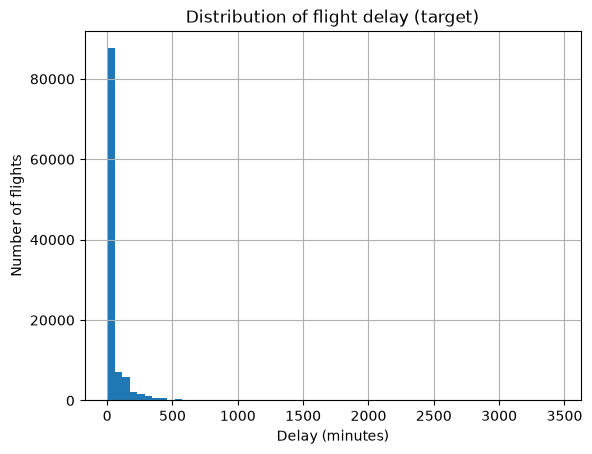

In [54]:
import matplotlib.pyplot as plt

train["target"].hist(bins=60)
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of flights")
plt.title("Distribution of flight delay (target)")
plt.show()

**Before this step:** The full-range histogram above stretches all the way out to 3451 minutes, so almost all flights get squashed into a single tall bar near zero — it's hard to see any real shape in the bulk of the data.

**What this code does:** Draws the same kind of histogram, but only for flights delayed 1500 minutes or less, temporarily hiding the handful of most extreme outliers. This doesn't change or remove any data — `train` itself is untouched, we're just choosing what to display in this one chart.

**What we want to get out of it:** A clearer, more readable view of how delays are distributed for the typical flight, without a few extreme outliers stretching the chart out of proportion.

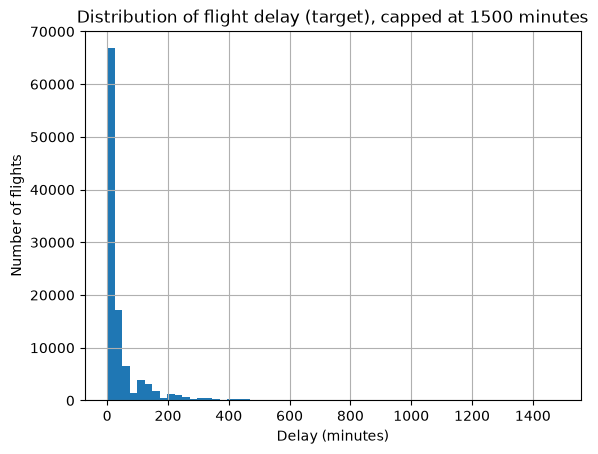

In [55]:
train.loc[train["target"] <= 1500, "target"].hist(bins=60)
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of flights")
plt.title("Distribution of flight delay (target), capped at 1500 minutes")
plt.show()

**Takeaway (Phase 1.3):** The distribution is heavily **right-skewed** — the vast majority of flights (around 65,000+) are delayed by roughly 0-20 minutes, with the bar count dropping off sharply after that. By around 400-500 minutes there are barely any flights left, and this chart doesn't even show the most extreme cases (delays stretch out to 3451 minutes in the uncapped view). This "long tail" shape is typical for delay data: being on time or slightly late is normal, while very long delays are rare but do happen. This confirms what the `.describe()` numbers suggested and sets up the next step, where we decide how to handle those rare extreme values.

**Before this step:** We've looked closely at the target's shape; one more basic data-quality check is worth doing while we're here.

**What this code does:** Counts how many rows in `train` are exact duplicates of another row.

**What we want to get out of it:** Peace of mind that we're not accidentally double-counting any flights before building anything on top of this data.

In [56]:
# Check for exact duplicate rows.
print("Duplicate rows in train:", train.duplicated().sum())

Duplicate rows in train: 0


## Phase 1.4: Analyze target distribution and flag outliers/impossible values

**Before this step:** We've seen visually that a small number of flights have very large delays, but we haven't quantified exactly how many, or double-checked that nothing in the data is outright impossible (like a negative delay).

**What this code does:** Confirms again there are zero negative delays (which would be an impossible value), then counts how many flights fall above a few different delay thresholds (500, 1000, 2000 minutes).

**What we want to get out of it:** A concrete count of how many "extreme" flights we're actually talking about, so we can make an informed decision about whether to drop, cap, or keep them — rather than guessing from the chart alone.

In [57]:
print("Negative delays (impossible):", (train["target"] < 0).sum())
for threshold in (500, 1000, 2000):
    count = (train["target"] > threshold).sum()
    pct = count / len(train) * 100
    print(f"Flights delayed more than {threshold} min: {count} ({pct:.2f}%)")

Negative delays (impossible): 0
Flights delayed more than 500 min: 1185 (1.10%)
Flights delayed more than 1000 min: 197 (0.18%)
Flights delayed more than 2000 min: 44 (0.04%)


**Decision (Phase 1.4):** No impossible values were found — zero negative delays. Extreme delays are rare (1,185 flights, 1.10%, over 500 min; 197, 0.18%, over 1000 min; 44, 0.04%, over 2000 min) but not data errors — they most likely reflect genuine severe disruptions (weather, mechanical issues, crew problems), not mistakes in the data.

**We are keeping all rows, with no drop or cap on `target`.** Since our evaluation metric is RMSE, which specifically rewards correctly capturing the full distribution (including the tail), removing or capping this small fraction would only discard real signal about the kind of large delays an airline operations team most needs to anticipate — without fixing anything that's actually wrong.

## Phase 1.5: Investigate temporal range and ordering of DATOP/STD/STA

**Before this step:** The `STD` column (scheduled departure time) is stored as plain text, like `"2016-01-03 10:30:00"`. To a computer, that's just a string of characters, not something it understands as an actual point in time — so it can't do date/time math with it (like sorting flights chronologically).

**What this code does:** It tells pandas to convert the `STD` column from plain text into a real date-and-time value it understands, for both the training and test data.

**What we want to get out of it:** A proper date/time column we can use later — for example, to sort flights by date or pull out things like the hour of departure.

In [58]:
# STD (scheduled time of departure) already uses colon-separated time
# (e.g. "10:30:00"), so it parses directly with pd.to_datetime.
for _df in (train, test):
    _df["STD"] = pd.to_datetime(_df["STD"])

train[["STD"]].head()

,STD
0,2016-01-03 10:30:00
1,2016-01-13 15:05:00
2,2016-01-16 04:10:00
3,2016-01-17 14:10:00
4,2016-01-17 14:30:00


**Before this step:** The `STA` column (scheduled arrival time) is also plain text, like `"2016-01-03 12.55.00"` — but notice it uses dots (`.`) between hours, minutes, and seconds instead of colons (`:`) like `STD` does. This is a data-entry inconsistency, and pandas can't understand `12.55.00` as a time on its own.

**What this code does:** First it fixes the formatting problem by swapping those dots for colons (so `"12.55.00"` becomes `"12:55:00"`), and only then converts the column into a real date/time value, the same as we did for `STD`.

**What we want to get out of it:** A properly formatted arrival-time column, consistent with `STD`, so we can compare or calculate with both departure and arrival times.

In [59]:
# STA (scheduled time of arrival) uses dots instead of colons in the time
# portion (e.g. "12.55.00" vs STD's "10:30:00") -- replace the last two dots
# with colons before parsing, since pd.to_datetime can't read this format
# directly.
def fix_sta_format(series):
    return series.str.replace(r"(\d{2})\.(\d{2})\.(\d{2})$", r"\1:\2:\3", regex=True)


for _df in (train, test):
    _df["STA"] = pd.to_datetime(fix_sta_format(_df["STA"]))

train[["STA"]].head()

,STA
0,2016-01-03 12:55:00
1,2016-01-13 16:55:00
2,2016-01-16 06:45:00
3,2016-01-17 17:00:00
4,2016-01-17 15:50:00


**Before this step:** `DATOP` (the date the flight actually operated) is still stored as plain text, like `"2016-01-03"`.

**What this code does:** Converts `DATOP` into a real date value, the same way we did for `STD` and `STA`.

**What we want to get out of it:** We'll need this later to split our data by time — training on earlier flights and testing on later ones — which only works if the dates are stored as actual dates the computer can order, not as plain text.

In [60]:
# DATOP (date of operation) is the flight's calendar date -- parse it to a
# real datetime so it can be used for the chronological train/test split later.
for _df in (train, test):
    _df["DATOP"] = pd.to_datetime(_df["DATOP"])

train[["DATOP"]].head()

,DATOP
0,2016-01-03
1,2016-01-13
2,2016-01-16
3,2016-01-17
4,2016-01-17


**Before this step:** `DATOP` is now a real date column, but we haven't checked what date range it covers or whether the rows are already in date order.

**What this code does:** Prints the earliest and latest `DATOP` date in the training data, and checks whether the rows are already sorted from earliest to latest.

**What we want to get out of it:** The date range tells us how much time the dataset spans (useful for picking a sensible split point). Knowing whether it's already sorted tells us whether we need to sort it ourselves before slicing it into "earlier" and "later" chunks.

In [61]:
# Check the date range and whether rows already come in chronological order.
print("Earliest DATOP:", train["DATOP"].min())
print("Latest DATOP:", train["DATOP"].max())
print("Already sorted by DATOP:", train["DATOP"].is_monotonic_increasing)

Earliest DATOP: 2016-01-01 00:00:00
Latest DATOP: 2018-12-31 00:00:00
Already sorted by DATOP: False


**Before this step:** We've confirmed `DATOP`'s overall range and that it isn't already sorted, but we haven't checked whether `STD` and `STA` make sense *relative to each other* for the same flight — an arrival should essentially never be scheduled before its own departure.

**What this code does:** Computes, for every flight, the time difference between `STA` and `STD` (arrival minus departure), then checks how many rows come out negative, and summarizes the typical flight duration this implies.

**What we want to get out of it:** Confirms there's no scheduling nonsense in the data (like an arrival scheduled before its own departure), which would flag a data-quality issue worth fixing before we build any features from these columns.

In [62]:
flight_duration = train["STA"] - train["STD"]
print("Negative STA-STD (arrival before departure):", (flight_duration < pd.Timedelta(0)).sum())
print("Flight duration (hours) summary:")
print((flight_duration.dt.total_seconds() / 3600).describe())

Negative STA-STD (arrival before departure): 0
Flight duration (hours) summary:
count    107833.000000
mean          3.710495
std          84.632836
min           0.166667
25%           1.583333
50%           2.333333
75%           2.750000
max       11992.000000
dtype: float64


**Important caveat — timezones:** The duration above (`STA - STD`) is *naive* — it treats both times as if they were in the same timezone. But airline schedules record each time in the **local time of its own airport**. For a domestic flight (departure and arrival in the same timezone) that's fine, but for an international leg (e.g. `CMN` in Casablanca → `TUN` in Tunis) the raw subtraction is off by the timezone gap, which can make the "duration" look implausibly short or long — a timezone artifact, not a real flight time.

**What this code does:** We already have `dep_tz`/`arr_tz` from the Phase 1.2 airport enrichment, so we can test this directly. It splits flights into two groups — same-timezone vs. cross-timezone — and compares the naive duration in each.

**What we want to get out of it:** Confirmation of whether the timezone effect actually shows up. If cross-timezone flights show wider or odder durations than same-timezone ones, that tells us any real duration-based feature we build later (Phase 2.3) must convert to a common timezone (e.g. UTC) first. *(Note: the huge max above, ~11,992 hours ≈ 500 days, is far too large to be a timezone effect — that points to a separate data-entry issue, likely a wrong date in a few `STA` values.)*

In [63]:
# Compare naive flight duration for same-timezone vs cross-timezone flights.
same_tz = train["dep_tz"] == train["arr_tz"]
dur_hours = (train["STA"] - train["STD"]).dt.total_seconds() / 3600

print(f"Same-timezone flights:  {same_tz.sum():>6} ({same_tz.mean() * 100:.1f}%)")
print(f"Cross-timezone flights: {(~same_tz).sum():>6} ({(~same_tz).mean() * 100:.1f}%)")
print("\nNaive duration (hours) -- SAME timezone:")
print(dur_hours[same_tz].describe())
print("\nNaive duration (hours) -- CROSS timezone:")
print(dur_hours[~same_tz].describe())

Same-timezone flights:   18901 (17.5%)
Cross-timezone flights:  88932 (82.5%)

Naive duration (hours) -- SAME timezone:
count    18901.000000
mean         9.690046
std        202.034847
min          0.166667
25%          0.750000
50%          1.000000
75%          3.000000
max      11992.000000
dtype: float64

Naive duration (hours) -- CROSS timezone:
count    88932.000000
mean         2.439642
std          1.000068
min          0.166667
25%          1.750000
50%          2.333333
75%          2.750000
max          8.916667
dtype: float64


**Takeaway (timezones):** The result is the opposite of the naive worry — the **cross-timezone** flights (82.5% of the data) are actually the *clean* group: median 2.3h, 75th percentile 2.75h, max ~8.9h, with a tight spread. That makes sense once you remember Tunisair's network is mostly Tunisia ↔ Europe/North Africa, where timezone offsets are small (roughly 0–2 hours) — not enough to distort a 1–4 hour flight into anything implausible.

The extreme values (max ~11,992h) are concentrated in the **same-timezone** group, where the offset is exactly zero — so they *cannot* be a timezone artifact. This confirms they're **data-entry errors** (a wrong date in a few `STA` values), a separate issue from timezones.

**Two conclusions for later:**
1. **Timezone conversion (Phase 2.3):** still worth doing for a precise flight-duration feature, but the effect here is modest — it won't make or break the model.
2. **Data-quality flag:** a small number of corrupted `STA` dates exist. They don't affect the `target` column (our label is clean), but they *would* poison any duration-based feature — so we'll need to clean or clip those before Phase 2.3.

**Before this step:** We know `train`'s `DATOP` spans 2016-01-01 to 2018-12-31, but we haven't looked at the test set's date range at all, or confirmed whether test flights come strictly after train flights in time — which matters for building a leakage-safe chronological split later (Phase 2.5).

**What this code does:** Prints the earliest and latest `DATOP` in `test`, the same way we did for `train`, then directly checks whether every train date comes before every test date.

**What we want to get out of it:** A clear, documented statement of whether test data comes strictly after train data in time, or whether the two overlap/interleave — this is exactly what Phase 1.5 needs to conclude.

In [64]:
print("Earliest DATOP (test):", test["DATOP"].min())
print("Latest DATOP (test):", test["DATOP"].max())
print("Train max DATOP <= Test min DATOP:", train["DATOP"].max() <= test["DATOP"].min())

Earliest DATOP (test): 2016-05-01 00:00:00
Latest DATOP (test): 2018-09-29 00:00:00
Train max DATOP <= Test min DATOP: False


**Takeaway (Phase 1.5):**

- **Date range:** `train` spans 2016-01-01 to 2018-12-31; `test` spans 2016-05-01 to 2018-09-29.
- **Chronological structure:** `DATOP` is *not* already sorted in `train`. No arrival is scheduled before its own departure (0 negative `STA - STD`), but a small number of flights show wildly large durations (max ~11,992h) — traced above to date-entry errors in a few `STA` values, not timezone effects. These don't affect the `target` label but must be handled before building any duration feature (Phase 2.3).
- **Train vs. test:** test does **not** come strictly after train in time — the two date ranges overlap almost entirely. On top of that, `test.csv` has no `target` column at all, confirming it's the unlabeled Zindi submission file, not a held-out validation set we can score locally.

**Implication for Phase 2.5:** we can't treat the provided `train`/`test` files as a ready-made chronological split — they're not split by time. Our own train/validation split needs to be carved out of `train` itself using a date cutoff, and `test` stays reserved purely for generating final Zindi submission predictions.

## Phase 1.6: Audit DELAY1-4/DUR1-4/ATD/ATA columns for leakage

**Correction:** the columns assumed earlier (`ETD`, `ETA`, `ATD`, `ATA`, `DELAY1-4`, `DUR1-4`) do not exist in this dataset. The actual columns in `train.csv` are: `ID`, `DATOP`, `FLTID`, `DEPSTN`, `ARRSTN`, `STD`, `STA`, `STATUS`, `AC`, `target`.

| Column | Known before departure? | Notes |
|---|---|---|
| DATOP, FLTID, DEPSTN, ARRSTN, STD, STA, AC | Yes | Schedule/route/aircraft — safe to use as features |
| STATUS | No | Observed values: `ATA` (93,679), `SCH` (13,242), `DEP` (467), `RTR` (294), `DEL` (151). These describe the flight's actual/operational state (e.g. `ATA` = already arrived), which is only known after the fact — leakage, drop from features |
| target | N/A | The label itself — the delay duration to predict |

Note: `STA` uses dots as a time separator (e.g. `12.55.00`) while `STD` uses colons (`10:30:00`) — a formatting inconsistency handled in Phase 1.5 above.

## Phase 1.7: Visualize delay patterns (route, aircraft, time-of-day, day-of-week, season)

We explore how delay relates to five factors: **route**, **aircraft**, **hour of day**, **day of week**, and **month/season**.

**A note on median vs. mean:** because `target` is heavily right-skewed (a few enormous delays, most flights near zero — see Phase 1.3/1.4), we summarize each category by its **median** delay rather than the mean. The median tells us what a *typical* flight in that group experiences, without a handful of extreme delays dragging the number up and hiding the real pattern.

The temporal fields used below (`dep_hour`, `dep_dow`, `dep_month`) are derived here just for exploration — they get formally engineered as model features later, in Phase 2.2.

**Before this step:** We have `DEPSTN`/`ARRSTN` and a parsed `STD` datetime, but not yet the convenient breakdown fields (a single route label, and the departure hour/weekday/month) that the plots below group by.

**What this code does:** Adds four temporary helper columns to `train`: `route` (e.g. `"TUN->ORY"`), and `dep_hour`, `dep_dow` (0 = Monday), `dep_month` pulled out of the scheduled departure time.

**What we want to get out of it:** Ready-to-group columns so each of the five plots below is a simple one-liner. (These are exploratory — the model's real temporal features are built cleanly in Phase 2.2.)

In [65]:
# Temporary EDA helper columns (formal feature engineering happens in Phase 2.2).
train["route"] = train["DEPSTN"] + "->" + train["ARRSTN"]
train["dep_hour"] = train["STD"].dt.hour
train["dep_dow"] = train["STD"].dt.dayofweek  # 0 = Monday, 6 = Sunday
train["dep_month"] = train["STD"].dt.month

train[["route", "dep_hour", "dep_dow", "dep_month"]].head()

,route,dep_hour,dep_dow,dep_month
0,CMN->TUN,10,6,1
1,MXP->TUN,15,2,1
2,TUN->IST,4,5,1
3,DJE->NTE,14,6,1
4,TUN->ALG,14,6,1


### Plot 1 — Delay by route

**What this code does:** Takes the 12 busiest routes (most flights), computes each one's median delay, and draws a horizontal bar chart sorted worst-to-best. We limit to busy routes so each bar is backed by enough flights to be meaningful.

**What we want to get out of it:** See whether some routes are systematically more delay-prone than others — a strong route effect would make route a valuable feature.

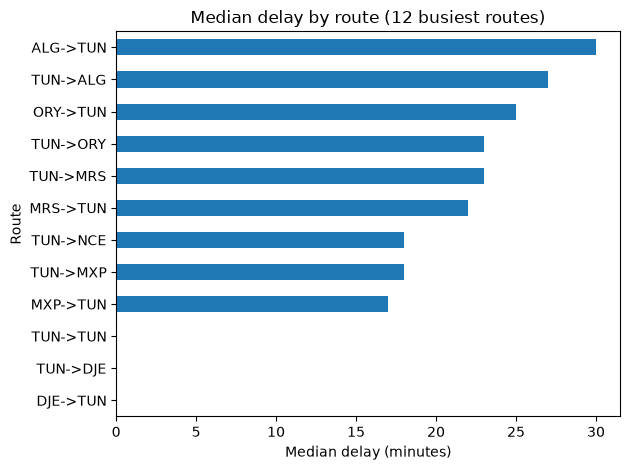

In [66]:
top_routes = train["route"].value_counts().head(12).index
route_median = (
    train[train["route"].isin(top_routes)]
    .groupby("route")["target"]
    .median()
    .sort_values()
)

route_median.plot(kind="barh")
plt.xlabel("Median delay (minutes)")
plt.ylabel("Route")
plt.title("Median delay by route (12 busiest routes)")
plt.tight_layout()
plt.show()

**Takeaway:** Clear route effect. Algiers routes (`ALG->TUN` ~30 min, `TUN->ALG` ~27 min) and the Paris-Orly / Marseille routes (~23–25 min) are the most delay-prone, while `DJE->TUN`, `TUN->DJE`, and `TUN->TUN` sit at a median of **0 minutes** (typically on time). Route clearly carries signal worth feeding the model. *(Side note: `TUN->TUN` — same departure and arrival — is an oddity, likely maintenance/positioning flights; flagged for a closer look but harmless to the label.)*

### Plot 2 — Delay by aircraft

**What this code does:** Same idea as the route plot, but grouping by individual aircraft (`AC`) — the 12 most-used tail numbers, by median delay.

**What we want to get out of it:** Check whether specific aircraft are reliably more delayed (which could hint at older or maintenance-heavy planes), or whether delay is spread evenly across the fleet.

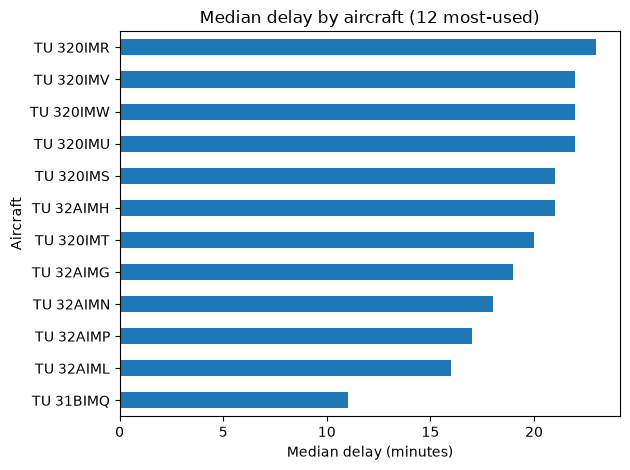

In [67]:
top_ac = train["AC"].value_counts().head(12).index
ac_median = (
    train[train["AC"].isin(top_ac)]
    .groupby("AC")["target"]
    .median()
    .sort_values()
)

ac_median.plot(kind="barh")
plt.xlabel("Median delay (minutes)")
plt.ylabel("Aircraft")
plt.title("Median delay by aircraft (12 most-used)")
plt.tight_layout()
plt.show()

**Takeaway:** Much weaker effect than route. Across the busiest aircraft the median delay sits in a narrow band (~11–23 min), with no dramatic outlier plane. Aircraft identity looks like a **minor** signal at best — worth including but unlikely to be a top predictor on its own.

### Plot 3 — Delay by hour of day

**What this code does:** Groups flights by their scheduled departure hour (0–23) and plots the median delay across the day as a line.

**What we want to get out of it:** Reveal any time-of-day pattern — for instance, delays building up through the day as knock-on effects accumulate, which is a well-known dynamic in aviation.

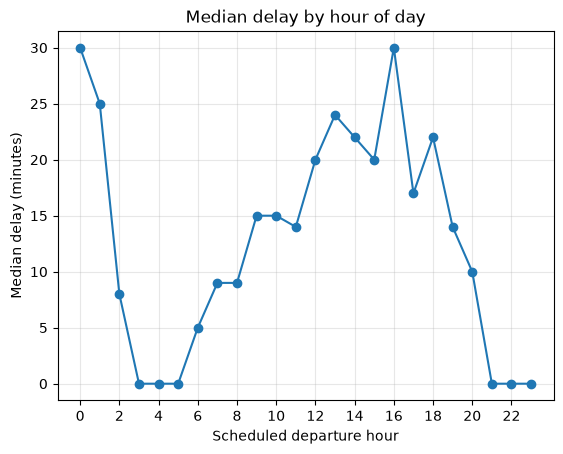

In [68]:
hour_median = train.groupby("dep_hour")["target"].median()

hour_median.plot(kind="line", marker="o")
plt.xlabel("Scheduled departure hour")
plt.ylabel("Median delay (minutes)")
plt.title("Median delay by hour of day")
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.show()

**Takeaway:** Strong time-of-day pattern. Early-morning departures (roughly 3–6 AM) start the day essentially on time (median 0), then delay climbs through the day to afternoon peaks (~13:00 and ~16:00 hit 20–30 min) — consistent with delays cascading as the day progresses. The very late-night hours (0–1 AM) are also high, likely the tail end of a delayed day's schedule. Departure hour is a **strong, intuitive** predictor.

### Plot 4 — Delay by day of week

**What this code does:** Groups flights by weekday of scheduled departure (Monday–Sunday) and plots the median delay for each.

**What we want to get out of it:** Check for a weekly rhythm — e.g. busier travel days (weekends) running later than mid-week.

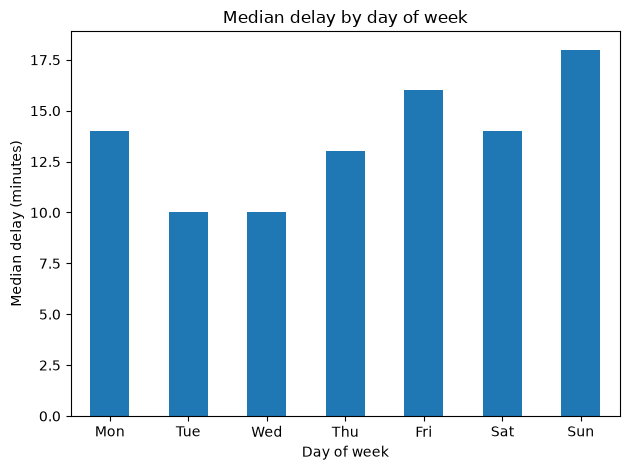

In [69]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_median = train.groupby("dep_dow")["target"].median()
dow_median.index = day_names

dow_median.plot(kind="bar")
plt.xlabel("Day of week")
plt.ylabel("Median delay (minutes)")
plt.title("Median delay by day of week")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Takeaway:** Mild effect. Delays are fairly flat across the week, dipping slightly mid-week (Tue/Wed ~10 min) and peaking on **Sunday** (~18 min) — plausibly the busiest leisure-travel day. Weekday is a **weak** signal — worth keeping but not a headline driver.

### Plot 5 — Delay by month (season)

**What this code does:** Groups flights by calendar month (1–12) and plots median delay, to expose any seasonal pattern.

**What we want to get out of it:** See whether busy travel seasons (e.g. summer holidays) run later than quieter months — a seasonal effect would make month a useful feature.

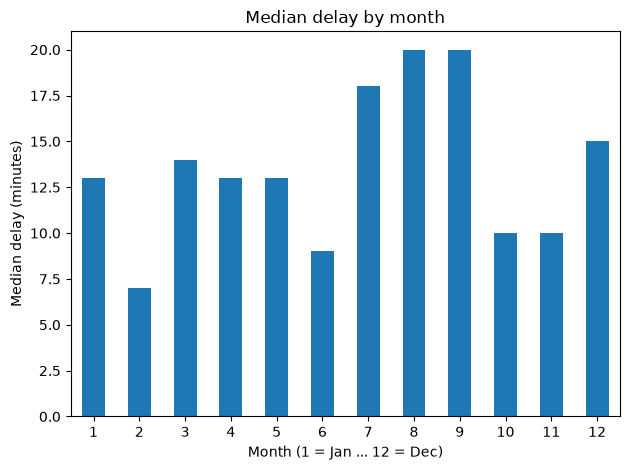

In [70]:
month_median = train.groupby("dep_month")["target"].median()

month_median.plot(kind="bar")
plt.xlabel("Month (1 = Jan ... 12 = Dec)")
plt.ylabel("Median delay (minutes)")
plt.title("Median delay by month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Takeaway:** Clear seasonal effect. Delays peak in the **summer travel season** — July (~18 min), August and September (~20 min) — and are lowest in **February** (~7 min). This matches the intuition that packed summer schedules leave less slack to absorb disruptions. Month/season is a **solid** predictor.

### Summary of Phase 1.7 — which factors drive delay?

Ranking the five factors by how strongly they relate to delay (all measured on median delay, since the target is right-skewed):

| Factor | Strength | What we saw |
|---|---|---|
| **Hour of day** | Strong | Delays cascade through the day — near-0 in the early morning, peaking 20–30 min in the afternoon |
| **Route** | Strong | Algiers/Orly/Marseille routes run ~23–30 min late; Djerba and same-airport flights ~0 |
| **Month / season** | Solid | Summer (Jul–Sep) ~18–20 min vs. February ~7 min |
| **Day of week** | Weak | Fairly flat; slight Sunday peak (~18 min) |
| **Aircraft** | Weak | Narrow ~11–23 min band across the fleet, no standout plane |

**Implication for Phase 2.1/2.2:** prioritize **departure hour, route, and month/season** as features. Day-of-week and aircraft are worth including but are unlikely to be primary drivers. This directly informs the leakage-safe feature set we define next.

## Phase 2.1: Define leakage-safe feature set

**Before this step:** Earlier, in the Leakage Audit above, we identified `STATUS` as a problem column. It tells us things like whether a flight already arrived (`ATA`) or was delayed (`DEL`) — information we'd only know *after* the flight happened. If we let a model see it, the model would be "cheating" by using information it wouldn't actually have available in real life when making a prediction ahead of time. This is called **data leakage**.

**What this code does:** Removes the `STATUS` column entirely from both the training and test data.

**What we want to get out of it:** A guarantee that our model can never accidentally use this after-the-fact information, so its performance reflects what it could really achieve in practice, before a flight happens.

In [71]:
# STATUS is leaky (see Leakage Audit above) -- it reflects the flight's
# actual/operational state, which is only known after the fact. Drop it from
# both train and test so it can never end up in the feature set.
for _df in (train, test):
    _df.drop(columns=["STATUS"], inplace=True)

train.columns.tolist()

['ID',
 'DATOP',
 'FLTID',
 'DEPSTN',
 'ARRSTN',
 'STD',
 'STA',
 'AC',
 'target',
 'dep_country',
 'dep_lat',
 'dep_lon',
 'dep_tz',
 'arr_country',
 'arr_lat',
 'arr_lon',
 'arr_tz',
 'route',
 'dep_hour',
 'dep_dow',
 'dep_month']

### The leakage-safe feature set

With `STATUS` dropped, here is the final list of what we will and won't feed the model. The guiding rule is the project's **golden rule**: every "keep" is information available **before** a flight departs. (This documents the decision — the columns themselves are engineered in Phases 2.2–2.4.)

**Keep — these become features:**

| Feature | Source | Why | Strength (from Phase 1.7) |
|---|---|---|---|
| Route | `DEPSTN`, `ARRSTN` | Some routes run systematically late | **Strong** |
| Departure hour | from `STD` (Phase 2.2) | Delays cascade through the day | **Strong** |
| Month / season | from `STD` (Phase 2.2) | Summer peaks, February lull | **Solid** |
| Day of week | from `STD` (Phase 2.2) | Mild weekly rhythm | Weak |
| Tunisia holiday flag | from `STD` (Phase 2.2) | Holidays shift traffic | To be tested |
| Aircraft | `AC` | Minor per-plane differences | Weak |
| Airport enrichment | `dep_*` / `arr_*` (Phase 1.2) | Feeds distance / country-pair / timezone features in Phase 2.3 | Feeds 2.3 |
| Route/airport engineered | Phase 2.3 | Great-circle distance, country pair, timezone gap | To be tested |
| Cascading prior-leg delay | Phase 2.4 | A plane running late tends to stay late | To be tested |

**Exclude:**

- **`STATUS`** — leaky (after-the-fact operational state), already dropped above.
- **`ID`, `FLTID`** — identifiers, no generalizable signal.
- **`target`** — the label we're predicting.
- **`STA` — handled with care.** Scheduled arrival *is* known before departure and is not itself leaky, but a few rows have corrupted arrival dates (see `ISSUES.md`) that would poison any duration feature. We therefore defer any `STA`-derived duration to Phase 2.3 and clean those rows first.

This is the contract the rest of Phase 2 builds against.

## Phase 2.2: Engineer temporal features

We turn the scheduled departure timestamp (`STD`) into model-ready time features: **departure hour**, **day of week**, **month**, and a **Tunisia public-holiday flag**. These formalize (on both `train` and `test`) the strongest time signals we found in the Phase 1.7 exploration. We derive from `STD` only — any `STA`-based duration is deferred to Phase 2.3, where the corrupted arrival dates are cleaned first (see `ISSUES.md`).

**Before this step:** We have a clean `STD` datetime, but a model can't directly use a full timestamp like `2016-01-03 10:30:00` — it needs the meaningful pieces pulled out. Earlier (Phase 1.7) we created hour/day-of-week/month on `train` only, just to draw the exploration charts.

**What this code does:** Formally creates three temporal feature columns — `dep_hour` (0–23), `dep_dow` (0 = Monday … 6 = Sunday), and `dep_month` (1–12) — on **both** the training and test data, so the model sees the same features when it learns and when it predicts.

**What we want to get out of it:** The strongest/solid time signals from our EDA (hour and month especially), available on both datasets and ready to feed a model.

In [72]:
# Temporal features from scheduled departure (STD), built on BOTH train and test
# so the model sees identical columns at fit and predict time.
for _df in (train, test):
    _df["dep_hour"] = _df["STD"].dt.hour
    _df["dep_dow"] = _df["STD"].dt.dayofweek   # 0 = Monday, 6 = Sunday
    _df["dep_month"] = _df["STD"].dt.month

train[["STD", "dep_hour", "dep_dow", "dep_month"]].head()

,STD,dep_hour,dep_dow,dep_month
0,2016-01-03 10:30:00,10,6,1
1,2016-01-13 15:05:00,15,2,1
2,2016-01-16 04:10:00,4,5,1
3,2016-01-17 14:10:00,14,6,1
4,2016-01-17 14:30:00,14,6,1


**Before this step:** We now have hour, weekday, and month, but there's one more calendar signal that plain date-math misses: **public holidays**. Travel patterns and airport congestion shift around holidays, and Tunisia's calendar includes Islamic holidays (Eid al-Fitr, Eid al-Adha, etc.) whose dates move by roughly 11 days each year — impossible to guess from the month or weekday alone.

**What this code does:** Uses the `holidays` package (a reference calendar, much like `airportsdata` was for airports) to get every Tunisian public holiday in 2016–2018, then adds a `dep_is_holiday` column that is `1` if a flight's departure date falls on one of those holidays and `0` otherwise — on both train and test.

**What we want to get out of it:** A simple yes/no holiday feature that lets the model react to holiday-driven changes in delay, capturing both the fixed civil holidays and the moving Islamic ones without us hand-entering any dates.

In [73]:
import holidays

# Tunisian public holidays across the years our data spans. This includes the
# moving Islamic holidays (Eid al-Fitr/Adha, etc.), which the package computes
# per year for us.
tn_holidays = holidays.Tunisia(years=[2016, 2017, 2018])

# Flag whether each flight's departure DATE is a public holiday (1/0).
# NOTE: match on .dt.date -- comparing against the holiday calendar by
# normalized Timestamp (.isin(tn_holidays)) silently returns all-False,
# because the calendar's keys are datetime.date, not Timestamp.
for _df in (train, test):
    _df["dep_is_holiday"] = _df["STD"].dt.date.map(lambda d: d in tn_holidays).astype(int)

print("Holiday dates in calendar (2016-2018):", len(tn_holidays))
print("Train flights on a holiday:", int(train["dep_is_holiday"].sum()),
      f'({train["dep_is_holiday"].mean() * 100:.1f}%)')
train[["STD", "dep_is_holiday"]].head()

Holiday dates in calendar (2016-2018): 51
Train flights on a holiday: 5797 (5.4%)


,STD,dep_is_holiday
0,2016-01-03 10:30:00,0
1,2016-01-13 15:05:00,0
2,2016-01-16 04:10:00,0
3,2016-01-17 14:10:00,0
4,2016-01-17 14:30:00,0


**Before this step:** We've created all four temporal features (`dep_hour`, `dep_dow`, `dep_month`, `dep_is_holiday`), but we shouldn't take on trust that they're correct — a subtle bug (like the holiday all-False gotcha) can silently produce wrong columns.

**What this code does:** Puts a few real flights side by side with the features we derived from them — a mix of ordinary days *and* known holidays — and adds two human-readable helper columns (`weekday_name`, `holiday_name`) purely so a person can eyeball that everything lines up. The helper columns are just for this check and aren't kept as model features.

**What we want to get out of it:** Direct confirmation against raw rows that hour/weekday/month are pulled out correctly and the holiday flag fires on (and only on) actual Tunisian holidays — this is the definition-of-done for this step.

In [74]:
# Spot-check the temporal features against a few raw rows: 3 ordinary days and
# 3 holiday flights. weekday_name / holiday_name are readable helpers for this
# check only -- they are NOT model features.
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
check_cols = ["STD", "dep_hour", "dep_dow", "dep_month", "dep_is_holiday"]

sample = pd.concat([
    train[train["dep_is_holiday"] == 0].head(3),
    train[train["dep_is_holiday"] == 1].head(3),
]).copy()
sample["weekday_name"] = sample["dep_dow"].map(dict(enumerate(day_names)))
sample["holiday_name"] = sample["STD"].dt.date.map(lambda d: tn_holidays.get(d))

sample[check_cols + ["weekday_name", "holiday_name"]]

,STD,dep_hour,dep_dow,dep_month,dep_is_holiday,weekday_name,holiday_name
0,2016-01-03 10:30:00,10,6,1,0,Sun,NaN
1,2016-01-13 15:05:00,15,2,1,0,Wed,NaN
2,2016-01-16 04:10:00,4,5,1,0,Sat,NaN
135,2016-07-08 06:30:00,6,4,7,1,Fri,عطلة عيد الفطر (تقديري)
136,2016-07-08 07:40:00,7,4,7,1,Fri,عطلة عيد الفطر (تقديري)
137,2016-07-08 08:00:00,8,4,7,1,Fri,عطلة عيد الفطر (تقديري)


## Phase 2.3: Engineer route/airport features via airportsdata

Using the Phase 1.2 airport enrichment (lat/lon, country, timezone for both airports), we build route-level features: **great-circle distance**, **timezone difference**, and a **country pair / domestic flag**. All of these come from coordinates and timezones only — none depend on the corrupted `STA` column, so no cleanup is needed here. (A scheduled-*duration* feature, which would need `STA` cleaned first, is deferred as a Phase 6.2 candidate — see `ISSUES.md`.)

**Before this step:** Our data knows *which* airports a flight connects, but not *how far apart* they are — and distance is one of the most basic drivers of flight length (and the operational complexity that can come with it). We already have each airport's latitude/longitude from the Phase 1.2 enrichment.

**What this code does:** Computes the great-circle distance (the shortest "as-the-crow-flies" distance over the Earth's surface, in kilometres) between the departure and arrival airports, using the standard haversine formula, and adds it as `gc_distance_km` on both train and test.

**What we want to get out of it:** A single numeric "how far is this flight" feature the model can use, derived cleanly from coordinates with no dependence on the corrupted `STA` column.

In [75]:
import numpy as np

def haversine_km(lat1, lon1, lat2, lon2):
    # Great-circle distance in km between two lat/lon points (haversine formula).
    r = 6371.0  # Earth's mean radius, km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

for _df in (train, test):
    _df["gc_distance_km"] = haversine_km(
        _df["dep_lat"], _df["dep_lon"], _df["arr_lat"], _df["arr_lon"]
    ).round(1)

train[["DEPSTN", "ARRSTN", "gc_distance_km"]].head()

,DEPSTN,ARRSTN,gc_distance_km
0,CMN,TUN,1663.6
1,MXP,TUN,984.2
2,TUN,IST,1669.5
3,DJE,NTE,1805.2
4,TUN,ALG,624.7


**Before this step:** A flight that crosses timezones effectively "gains" or "loses" clock hours, which shifts how its schedule sits relative to the destination's operating day. We have each airport's timezone from Phase 1.2, but not yet a single number capturing the gap between them — and that gap isn't fixed, because daylight-saving time moves it around during the year (e.g. Tunis↔Paris is 0 hours in winter but 1 hour in summer).

**What this code does:** For each flight, it works out the departure airport's UTC offset and the arrival airport's UTC offset *on that flight's date* (so daylight saving is handled correctly), then stores their difference as `tz_diff_hours` (arrival minus departure), on both train and test. We evaluate both offsets at the scheduled departure date, so this never touches the corrupted `STA` column.

**What we want to get out of it:** A compact east/west "timezone shift" feature (0 for domestic flights, positive heading east, negative heading west) that the model can use, correctly reflecting daylight saving rather than a crude fixed offset.

In [76]:
def tz_offset_hours(std, tz_series):
    # UTC offset (in hours) of each row's timezone, evaluated at its own STD date
    # so daylight saving is handled. Grouped by timezone name so tz_localize can
    # run vectorized per group rather than row by row.
    out = pd.Series(index=std.index, dtype=float)
    for tzname, idx in std.groupby(tz_series).groups.items():
        local = std.loc[idx].dt.tz_localize(
            tzname, ambiguous="NaT", nonexistent="shift_forward"
        )
        utc = local.dt.tz_convert("UTC").dt.tz_localize(None)
        out.loc[idx] = (std.loc[idx] - utc).dt.total_seconds() / 3600
    return out

for _df in (train, test):
    dep_off = tz_offset_hours(_df["STD"], _df["dep_tz"])
    arr_off = tz_offset_hours(_df["STD"], _df["arr_tz"])
    _df["tz_diff_hours"] = arr_off - dep_off

train[["DEPSTN", "ARRSTN", "dep_tz", "arr_tz", "tz_diff_hours"]].head()

,DEPSTN,ARRSTN,dep_tz,arr_tz,tz_diff_hours
0,CMN,TUN,Africa/Casablanca,Africa/Tunis,1.0
1,MXP,TUN,Europe/Rome,Africa/Tunis,0.0
2,TUN,IST,Africa/Tunis,Europe/Istanbul,1.0
3,DJE,NTE,Africa/Tunis,Europe/Paris,0.0
4,TUN,ALG,Africa/Tunis,Africa/Algiers,0.0


**Before this step:** We have distance and timezone shift, but not a simple view of the *countries* a flight connects — in particular whether it's a domestic hop (both airports in Tunisia) or an international leg. Domestic and international flights often behave quite differently operationally.

**What this code does:** Adds two columns on both train and test: `is_domestic` (1 if the departure and arrival countries are the same, else 0), and `country_pair` (a label like `"TN->FR"`) capturing the directional country-to-country relationship.

**What we want to get out of it:** A clean domestic/international flag plus a country-pair grouping the model can learn from, complementing the finer-grained route (`DEPSTN->ARRSTN`) we already have.

In [77]:
for _df in (train, test):
    _df["is_domestic"] = (_df["dep_country"] == _df["arr_country"]).astype(int)
    _df["country_pair"] = _df["dep_country"] + "->" + _df["arr_country"]

print("Domestic share (train):", f'{train["is_domestic"].mean() * 100:.1f}%')
print("Distinct country pairs (train):", train["country_pair"].nunique())
train[["DEPSTN", "ARRSTN", "dep_country", "arr_country", "is_domestic", "country_pair"]].head()

Domestic share (train): 17.5%
Distinct country pairs (train): 195


,DEPSTN,ARRSTN,dep_country,arr_country,is_domestic,country_pair
0,CMN,TUN,MA,TN,0,MA->TN
1,MXP,TUN,IT,TN,0,IT->TN
2,TUN,IST,TN,TR,0,TN->TR
3,DJE,NTE,TN,FR,0,TN->FR
4,TUN,ALG,TN,DZ,0,TN->DZ


**Before this step:** We've built three route/airport features (`gc_distance_km`, `tz_diff_hours`, `is_domestic`/`country_pair`), but we shouldn't trust them without checking a few flights we can reason about by hand.

**What this code does:** Picks a handful of well-known routes and shows, for each, the computed distance and the timezone-difference range (min / median / max across the year, so daylight-saving movement is visible) plus the domestic flag.

**What we want to get out of it:** Direct confirmation that the numbers match reality — short domestic hops are ~hundreds of km with a 0-hour shift, longer international legs are ~1,000-3,000 km with sensible east/west shifts — which is the definition-of-done for this step.

In [78]:
# Sanity-check the route/airport features against a few known routes.
# tz_diff is shown as min/median/max because daylight saving moves it during the year.
train["route"] = train["DEPSTN"] + "->" + train["ARRSTN"]  # already exists from Phase 1.7; harmless to reaffirm

known_routes = ["TUN->DJE", "TUN->ALG", "TUN->IST", "MXP->TUN", "TUN->CDG", "TUN->JED"]
rows = []
for r in known_routes:
    s = train[train["route"] == r]
    if len(s):
        rows.append({
            "route": r,
            "n": len(s),
            "gc_distance_km": s["gc_distance_km"].iloc[0],
            "tz_diff_min": s["tz_diff_hours"].min(),
            "tz_diff_median": s["tz_diff_hours"].median(),
            "tz_diff_max": s["tz_diff_hours"].max(),
            "is_domestic": s["is_domestic"].iloc[0],
        })
pd.DataFrame(rows)

,route,n,gc_distance_km,tz_diff_min,tz_diff_median,tz_diff_max,is_domestic
0,TUN->DJE,3521,334.6,0.0,0.0,0.0,1
1,TUN->ALG,1564,624.7,0.0,0.0,0.0,0
2,TUN->IST,1436,1669.5,1.0,2.0,2.0,0
3,MXP->TUN,1466,984.2,-1.0,-1.0,0.0,0
4,TUN->CDG,323,1487.9,0.0,1.0,1.0,0
5,TUN->JED,911,3254.2,2.0,2.0,2.0,0


**Takeaway (Phase 2.3):** The features check out against reality:

| Route | Distance | tz_diff (min/med/max) | Notes |
|---|---|---|---|
| `TUN->DJE` | ~335 km | 0 / 0 / 0 | Domestic hop, no shift ✓ |
| `TUN->ALG` | ~625 km | 0 / 0 / 0 | International but Algeria shares Tunisia's offset — good edge case (tz_diff 0 ≠ domestic) ✓ |
| `TUN->IST` | ~1,670 km | +1 / +2 / +2 | Eastbound; +1 in early 2016, +2 after Turkey's permanent switch ✓ |
| `MXP->TUN` | ~984 km | −1 / −1 / 0 | Westbound from Italy; DST-dependent ✓ |
| `TUN->CDG` | ~1,488 km | 0 / +1 / +1 | Paris; 0 in winter, +1 in summer (DST) ✓ |
| `TUN->JED` | ~3,254 km | +2 / +2 / +2 | Longest leg, furthest east ✓ |

Distances scale correctly with geography and the timezone differences move with daylight saving as expected. Route/airport features are ready. (Domestic flights are ~17.5% of the data.)

## Phase 2.4: Engineer cascading-delay feature (prior leg delay per aircraft)

*Not started yet (Backlog). Will compute, per aircraft (`AC`), whether/how much its previous scheduled leg was delayed — using only prior, not future, legs, to stay leakage-safe.*

## Phase 2.5: Build chronological train/test split

Chronological split (not random) — confirm `DATOP` ordering first (Phase 1.5, done above), then split by a date cutoff so validation data always follows training data in time.

*Not started yet (Backlog) — the actual split by date cutoff goes here.*

## Phase 3.1: Build baseline model and compute RMSE

Heuristic baseline (e.g. mean delay, or mean delay per route) scored with RMSE — the number every later model has to beat.

*Not started yet (Backlog).*

## Phase 3.2: Document business framing (stakeholder, metric, baseline score)

**Stakeholder:** an airline operations team (and, downstream, a travel app surfacing delay risk to passengers).

**Prediction:** the delay duration of a scheduled Tunisair flight, using only information known before departure (schedule, route, aircraft) — never the actual departure/arrival times or recorded delay-reason codes, which only exist after the fact.

**Evaluation metric:** RMSE (minutes), matching the Zindi competition metric. This penalizes large misses more than small ones and stays interpretable in the same units as the target.

This is a **regression** problem: the target `target` is a continuous delay duration.

## Phase 4.1: Train Linear Regression with cross-validation

*Not started yet (Backlog).*

## Phase 4.2: Train Random Forest with cross-validation

*Not started yet (Backlog).*

## Phase 4.3: Train Gradient Boosting/XGBoost with cross-validation

*Not started yet (Backlog).*

## Phase 4.4: Hyperparameter tuning for best-performing algorithm(s)

*Not started yet (Backlog).*

## Phase 4.5: Compare all models and select the best

*Not started yet (Backlog).*

## Phase 5.1: Draft stakeholder slide deck

*Tracked outside this notebook — this is the slide deck deliverable, not notebook code.*

## Phase 6.1: Residual/error analysis

Residuals by route, season, aircraft, and delay magnitude.

*Not started yet (Backlog).*

## Phase 6.2: Iterate features/model based on error analysis

*Not started yet (Backlog).*

## Phase 6.3: Final evaluation on held-out test set

Score the selected model once on the held-out test set and save it with `joblib` for use in the Phase 8 web app.

*Not started yet (Backlog).*

## Phase 7.1: Finalize PEP8, reproducible notebook

*Ongoing — a final pass on this notebook's style and reproducibility once modeling is complete.*

## Phase 7.2: Finalize slide deck (PDF)

*Tracked outside this notebook.*

## Phase 7.3: Add data product slide

*Tracked outside this notebook.*

## Phase 7.4: Rehearse and deliver the presentation

*Tracked outside this notebook.*

## Phase 8.1: Define delay-risk categories and alternative-flight logic

*Tracked in a separate Streamlit app, not this notebook.*

## Phase 8.2: Build Streamlit app - input flight, show predicted delay + risk category

*Tracked in a separate Streamlit app, not this notebook.*

## Phase 8.3: Add alternative-flight suggestion feature

*Tracked in a separate Streamlit app, not this notebook.*

## Phase 8.4: Polish app UI and prepare live demo for presentation

*Tracked in a separate Streamlit app, not this notebook.*